In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc

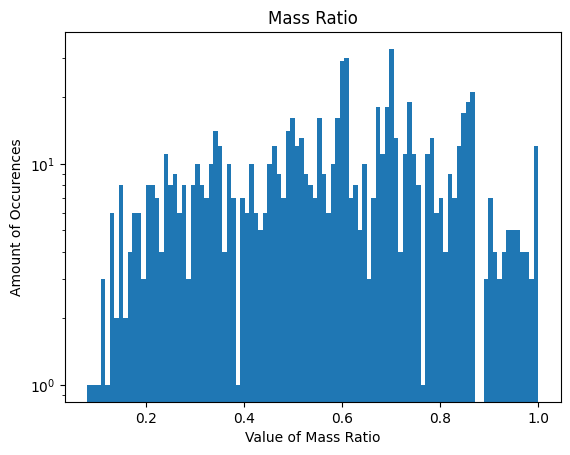

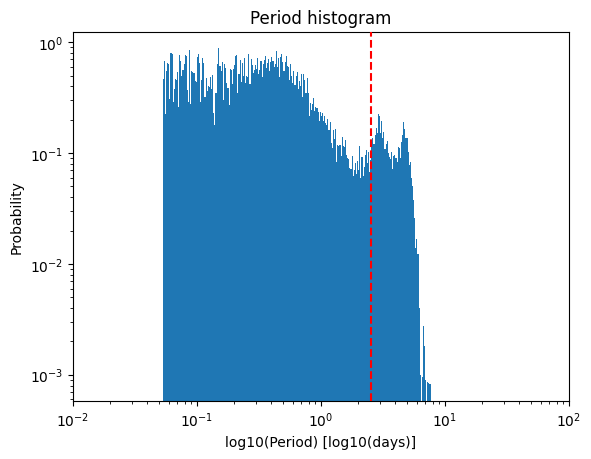

In [12]:
df = pd.read_csv(r'DATA/RAW/reduced_raw_data.csv')
eccentricity = df["e"]
mass_ratio = df["q"]
period = df["period"]
semi_major_ax = df["a"]
id = df["system_id"]

plt.hist(mass_ratio, log=True, bins=100)
plt.xlabel('Value of Mass Ratio')
plt.ylabel('Amount of Occurences')
plt.title('Mass Ratio')
plt.show()


bins = np.logspace(np.log10(period.min()),
                   np.log10(period.max()),
                   1000)
plt.hist(np.log10(period), log=True, bins=bins, density=True)
#plt.axvline(365, color = 'red', linestyle='dashed',zorder = 45)
plt.xlabel('log10(Period) [log10(days)]')
plt.ylabel('Probability')
plt.title('Period histogram')
plt.xlim(10**-2,10**2)
plt.xscale('log')
plt.axvline(np.log10(365), color = 'red', linestyle = 'dashed', zorder = 45)
plt.show()

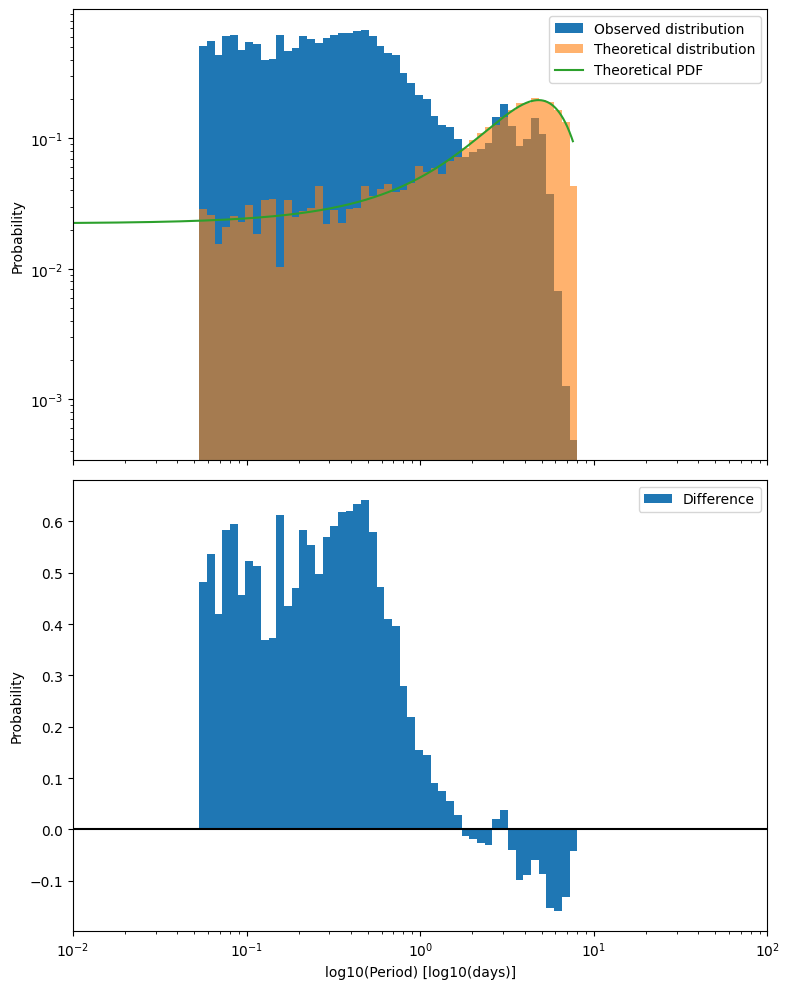

In [ ]:
#Bias in Mass ratio, for low ratios. One star is just that much heavier
#Duquennoy & Mayor (1991) https://academic.oup.com/mnras/article/417/3/1684/1084726?login=true
#https://ui.adsabs.harvard.edu/abs/1991A&A...248..485D 

def log_per_dist(lP):
    mu = 4.8
    sig = 2.3
    return 1/(sig*np.sqrt(2*np.pi)) * np.exp(-(lP-mu)**2/(2*sig**2))

N = 200
bins = np.logspace(np.log10(period.min()),np.log10(period.max()),N)

Pers = np.linspace(np.log10(period.min()),np.log10(period.max()),len(period))

# Observed histogram
hist_dat, bin_edges = np.histogram(np.log10(period),bins=bins,density=True)

bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Compute probabilities
p = log_per_dist(Pers)

# Normalize probabilities
p = p / p.sum()

# Sample according to theoretical distribution
samples = np.random.choice(Pers, size=len(period), p=p)

# Theoretical histogram
dist_dat, dist_edges = np.histogram(samples,bins=bins,density=True)

hist_diff = hist_dat - dist_dat

# Create 2 stacked subplots
fig, (ax1, ax2) = plt.subplots(2, 1,figsize=(8, 10),sharex=True)

#Top subplot
ax1.hist(np.log10(period),log=True,bins=bins,density=True,label='Observed distribution')

ax1.hist(samples,bins=bins,density=True,alpha=0.6,label='Theoretical distribution')

#Plot normalized PDF
ax1.plot(Pers,p / (Pers[1] - Pers[0]),label='Theoretical PDF')

ax1.set_xscale('log')
ax1.set_xlim(10**-2, 10**2)

ax1.set_ylabel('Probability')
ax1.legend()

#Bottom subplot
ax2.bar(bin_centers,hist_diff,width=np.diff(bin_edges),align='center',label='Difference')

ax2.axhline(0, color='black')

ax2.set_xscale('log')
ax2.set_xlim(10**-2, 10**2)

ax2.set_xlabel('log10(Period) [log10(days)]')
ax2.set_ylabel('Probability')
ax2.legend()

plt.title('')
plt.tight_layout()
plt.show()